# WGTDA: Patient Phenotype Prediction Tutorial

This tutorial demonstrates the **WGTDA prediction framework** for classifying patient phenotypes using gene expression data.

Each patient's gene expression profile is used to compute individual weights, which are used to construct a **simplicial complex** and compute **persistent homology**. The resulting topological features (persistence landscapes) are then used as input to a machine learning classifier and compared against a baseline trained on raw gene expression.

![Patient Prediction Framework](../../docs/imgs/ML_framework.png)


## Task Description

In this case we are predicting the **complete response chemotherapy agent** — a multi-class classification task that assigns each patient to one of three treatment regimens based on their tumour gene expression profile:
- **Cisplatin and cyclophosphamide**
- **Folinic acid, fluorouracil, and oxaliplatin (FOLFOX)**
- **Docetaxel and doxorubicin**

The dataset used is the **The Cancer Genome Atlas (TCGA)** cohort.

These chemotherapy regimens are widely used in clinical practice, and their associated transcriptomic profiles provide a real-world representation of drug-specific molecular responses across diverse tumour contexts. Predicting the administered treatment from RNA-seq data is clinically relevant because different agents induce distinct transcriptional programmes. However, this task remains challenging due to overlapping drug effects, tumour heterogeneity, and background biological variability — all of which complicate the disentanglement of drug-induced transcriptional signals from confounding biological noise.


## Tutorial Steps
1. Import required modules.
2. Load gene expression data (TCGA Chemotherapy Response).
3. Filter to significant genes and prepare the expression matrix.
4. Split data into train/test sets and encode labels.
5. Train a baseline Random Forest on raw gene expression.
6. Compute Co-expression Matrix and Generate Persistence Landscapes.
7. Train a Random Forest on WGTDA landscape features.
8. Compare classification performance between both approaches.


## Step 1: Import Modules

Import the required libraries:
- **`src.tda.pipeline_prediction`** — builds the simplicial complex, computes persistent homology, and extracts persistence landscapes per patient.
- **`src.correlation.dtem`** — computes the DTEM co-expression matrix used to weight the simplicial complex construction.
- **`sklearn`** — provides the Random Forest classifier, label encoding, and evaluation metrics.


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))
import pandas as pd
import numpy as np
import src.tda.pipeline_prediction as tda_pred
from sklearn.calibration import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import src.correlation.dtem as dtem

## Step 2: Load Gene Expression Data

Load the gene expression dataset. This tutorial uses the **TCGA Chemotherapy Agent** dataset, where each row is a patient sample and columns are gene FPKM values. A `phenotype` column encodes the treatment response label (**Resistant** or **Sensitive**), which is used as the classification target.


In [2]:
project_root = os.path.abspath('../..')
treatment_response_path = os.path.join(project_root, 'data/paper/clinical_outcome_prediction/treatment_agent_chemotherapy/fpkm_matrix.csv')
DEG_path = os.path.join(project_root, 'data/paper/clinical_outcome_prediction/treatment_agent_chemotherapy/DEG_genes.csv')

expression_matrix = pd.read_csv(treatment_response_path)
print(expression_matrix.head(2))

                                          Unnamed: 0   phenotype   TSPAN6  \
0  2a612640-5c9e-42b2-ac52-02a44b46d429.rna_seq.a...  CarboTamox  13.0316   
1  155b4627-6a5a-4991-a58e-609c4fcbd5b9.rna_seq.a...  CarboTamox   5.9402   

       TNMD     DPM1   SCYL3  C1orf112     FGR      CFH   FUCA2  ...  \
0  120.2058  16.7101  1.9527    0.5576  7.9533  30.9036  11.637  ...   
1    0.0000  31.7509  1.0922    1.2023  1.4310   9.8808  15.406  ...   

   ACTL10.3  AC119733.1  AC020765.6  AC010980.1  AC004233.4  AL451106.1  \
0       0.0         0.0      0.0046      0.0362         0.0         0.0   
1       0.0         0.0      0.0035      0.0321         0.0         0.0   

   AC008763.4  AC006486.3  AL391628.1  AP006621.6  
0      0.0045         0.0      0.0167      0.0746  
1      0.0000         0.0      0.0028      0.1052  

[2 rows x 20012 columns]


### Data Overview

Before proceeding, let's inspect the dataset dimensions and class balance to confirm the data loaded correctly.


In [3]:
print(f"Total samples : {expression_matrix.shape[0]}")
print(f"Total genes   : {expression_matrix.shape[1] - 1}")  # exclude phenotype column
print(f"\nClass distribution:\n{expression_matrix['phenotype'].value_counts()}")


Total samples : 1668
Total genes   : 20011

Class distribution:
phenotype
CisCyclo      574
DoxoPacli     285
Folfox        212
Docdox        200
CarboTamox    185
Etoposide     120
RituMetho      92
Name: count, dtype: int64


## Step 3: Gene Preselection

Due to the computational overhead of computing topological features in high-dimensional spaces, we restrict our analysis to a preselected set of **differentially expressed genes (DEGs)** between treatment-sensitive and treatment-resistant patients. This reduces the feature space while retaining the most biologically informative signal.


In [4]:
deg_df = pd.read_csv(DEG_path, index_col=0)

log2fc = 3.0
padj = 0.5

deg = deg_df[(deg_df["padj"] < padj) & (deg_df["log2FoldChange"].abs() > log2fc)]
gene_list = deg.index.intersection(expression_matrix.columns).tolist()

# Keep only the three chemotherapy classes
keep_classes = ["CisCyclo", "Folfox", "Docdox"]
expression_matrix = expression_matrix[expression_matrix["phenotype"].isin(keep_classes)]
phenotype = expression_matrix["phenotype"]

sig_exp_matrix = expression_matrix[gene_list].copy()
sig_exp_matrix["phenotype"] = phenotype.values

print(f"Samples : {sig_exp_matrix.shape[0]}")
print(f"DEGs    : {len(gene_list)}")
print(f"\nClass distribution:\n{sig_exp_matrix['phenotype'].value_counts()}")


Samples : 986
DEGs    : 283

Class distribution:
phenotype
CisCyclo    574
Folfox      212
Docdox      200
Name: count, dtype: int64


## Step 4: Split and Preprocess the Dataset

The filtered expression matrix is split into **training (70%)** and **test (30%)** sets using stratified sampling to preserve the class distribution of the `phenotype` label across both splits.

The feature matrix (`X`) and label vector (`y`) are then extracted separately:
- **`X_train_expr` / `X_test_expr`** — gene expression values (one row per patient, one column per DEG).
- **`y_train` / `y_test`** — treatment response labels, integer-encoded using `LabelEncoder` (e.g., `Resistant → 0`, `Sensitive → 1`).


In [5]:
train_df, test_df = train_test_split(
        sig_exp_matrix,
        test_size=0.3,
        random_state=2,
        stratify=sig_exp_matrix["phenotype"]
    )

print(train_df)

X_train_expr = train_df.drop(columns=["phenotype"]).values
X_test_expr = test_df.drop(columns=["phenotype"]).values
y_train = train_df["phenotype"].values
y_test = test_df["phenotype"].values

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

         CFTR     AOC1    USH1C  CEACAM7      NOX1    PRSS3     DPEP1  \
607    0.3547   0.5639   0.0880   0.1085    0.3207   0.0505    0.7099   
1531   1.0552  58.9302  12.5564   0.1888    0.3835   0.4994    2.7737   
1440   0.0000   0.1497   0.0626   0.0178    0.4087   0.0829    0.3365   
1503   0.3453   0.6786   1.5355   0.0835    0.5574   0.1088    0.3722   
333   41.1321  85.2511  45.3015  55.8258  203.9193  87.6447   75.5208   
...       ...      ...      ...      ...       ...      ...       ...   
1287   0.0307   2.5798   0.0871   0.3682    0.5761   0.3427    0.3569   
641    0.0072   0.1895   0.0000   0.0000    0.4232   0.1510    0.0262   
1291   0.0291   0.6347   0.0915   0.7257    0.2448   0.0813    0.3544   
1217   0.0498   0.1420   0.0395   0.1054    0.3975   0.0604    0.3929   
464   34.2706  64.3401  59.2291  48.4689   88.6283  48.5850  392.4731   

      CYP24A1  SERPINB3  CLDN18  ...      H4C4     H2BC7      H3C7     H2AC4  \
607    0.0601    0.0703  0.0452  ...    0.1

In [6]:
def train_rf(X_train, y_train, X_test, y_test, label: str):
    """Train a Random Forest and print metrics."""
    clf = RandomForestClassifier(random_state=1)

    print(f"\n🧬 Training Random Forest on {label}...")
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1w = f1_score(y_test, y_pred, average="weighted")

    print(f"➡ Results ({label}):")
    print(f"   Accuracy   : {acc:.3f}")
    print(f"   F1 weighted: {f1w:.3f}")

    return clf, acc, f1w

# Baseline: Random Forest on raw gene expression
_expr_clf, expr_acc, expr_f1 = train_rf(
    X_train_expr, y_train, X_test_expr, y_test,
    label="Raw Gene Expression (DEG)"
)




🧬 Training Random Forest on Raw Gene Expression (DEG)...
➡ Results (Raw Gene Expression (DEG)):
   Accuracy   : 0.547
   F1 weighted: 0.519


## Step 6: Compute DTEM Co-expression Matrix and Generate Persistence Landscapes

**6a — DTEM Co-expression Matrix**

The **Distance to Empirical Measure (DTEM)** is a robust, outlier-resistant co-expression measure. For each pair of genes, it computes the square norm between a data point $x$ and its $k$ nearest neighbours in the dataset $X_n$:

$$\rho = \frac{1}{k}\sum_{j=1}^{k}\|x - X_n\|_{(j)}^2$$

The $1/k$ normalisation factor reduces the influence of outliers, making the resulting gene × gene matrix a stable population-level reference for weighting each patient's simplicial complex.

> **Note:** The DTEM matrix is computed **only on the training set** to prevent data leakage; the same matrix is applied to the test set.




In [7]:
coexpression_matrix = dtem.compute_dtem_matrix(X_train_expr)

**6b — Persistence Landscapes (Train & Test)**

For each patient, `run_prediction_pipeline`:
1. Weights the patient's gene expression vector against the DTEM population matrix.
2. Builds a **Rips complex** and computes **persistent homology** in dimensions 0, 1, and 2.
3. Vectorises the birth–death intervals as **persistence landscapes**, which are concatenated into a fixed-length feature vector per patient.

**Key hyperparameters:**

| Parameter | Value | Description |
|---|---|---|
| `num_layers` | 2 | Number of landscape layers per homological dimension. More layers capture finer topological detail but increase feature size. |
| `resolution` | 100 | Number of sample points for the landscape function. Higher values give finer resolution at the cost of compute time. |
| `max_dim` | 2 | Maximum homological dimension. Dim 0 = connected components, Dim 1 = loops, Dim 2 = voids. |

In [8]:
num_layers = 2
resolution = 100
max_dim = 2

print("\n🏗 Computing TDA landscapes (train)...")
landscapes_train = tda_pred.run_prediction_pipeline(
        X_train_expr,
        coexpression_matrix,
        num_layers=num_layers,
        resolution=resolution,
        max_dim=max_dim,
    )
    
print("\n🏗 Computing TDA landscapes (test)...")
landscapes_test = tda_pred.run_prediction_pipeline(
        X_test_expr,
        coexpression_matrix,
        num_layers=num_layers,
        resolution=resolution,
        max_dim=max_dim,
    )
landscapes_train = np.nan_to_num(landscapes_train)
landscapes_test = np.nan_to_num(landscapes_test)


🏗 Computing TDA landscapes (train)...


Computing diagrams: 100%|██████████| 690/690 [01:25<00:00,  8.06it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value

🏗 Computing TDA landscapes (test)...


Computing diagrams: 100%|██████████| 296/296 [00:35<00:00,  8.23it/s]

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value



/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


## Step 7: Train Random Forest on TDA Landscape Features and Compare Results

Using the persistence landscape feature matrices computed in Step 6, we train a second **Random Forest classifier** — this time using topological features rather than raw gene expression values.

The final summary compares both classifiers side-by-side:
- **Raw Expression RF** — trained directly on DEG FPKM values (baseline).
- **WGTDA Landscapes RF** — trained on persistence landscape features derived from patient-level simplicial complexes.

A higher accuracy or F1-score for the WGTDA model demonstrates that the topological representation captures biologically meaningful structure beyond what is encoded in raw expression alone.


In [9]:
# Train Random Forest on TDA landscape features
_tda_clf, tda_acc, tda_f1 = train_rf(
    landscapes_train, y_train, landscapes_test, y_test,
    label="WGTDA Landscapes (DEG)"
)

print("\n✅ Summary:")
print(f"Raw Expression RF   -> Acc: {expr_acc:.3f}, F1w: {expr_f1:.3f}")
print(f"WGTDA Landscapes RF -> Acc: {tda_acc:.3f}, F1w: {tda_f1:.3f}")



🧬 Training Random Forest on WGTDA Landscapes (DEG)...
➡ Results (WGTDA Landscapes (DEG)):
   Accuracy   : 0.628
   F1 weighted: 0.558

✅ Summary:
Raw Expression RF   -> Acc: 0.547, F1w: 0.519
WGTDA Landscapes RF -> Acc: 0.628, F1w: 0.558


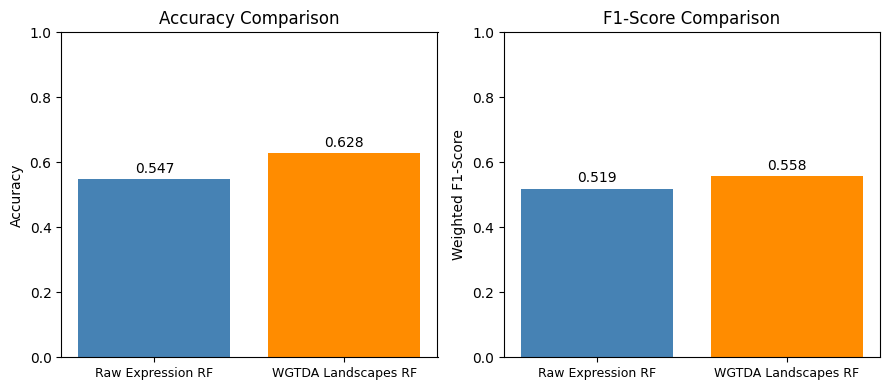

In [10]:
import matplotlib.pyplot as plt

models = ["Raw Expression RF", "WGTDA Landscapes RF"]
accuracies = [expr_acc, tda_acc]
f1_scores = [expr_f1, tda_f1]

x = range(len(models))
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].bar(x, accuracies, color=["steelblue", "darkorange"])
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy Comparison")
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

axes[1].bar(x, f1_scores, color=["steelblue", "darkorange"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Weighted F1-Score")
axes[1].set_title("F1-Score Comparison")
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()
